In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import kagglehub
import os
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [3]:
path = kagglehub.dataset_download("swoyam2609/fresh-and-stale-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/swoyam2609/fresh-and-stale-classification


In [4]:
print("Dataset path:", path)

for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

Dataset path: /kaggle/input/datasets/swoyam2609/fresh-and-stale-classification
fresh-and-stale-classification/
    dataset/
        Test/
            rottenbanana/
            freshokra/
            rottenpatato/
            rottenokra/
            freshoranges/
            rottenoranges/
            freshcucumber/
            freshbanana/
            rottentamto/
            rottencucumber/
            freshpatato/
            rottenapples/
            freshapples/
            freshtamto/
        Train/
            rottenbanana/
            freshpotato/
            freshokra/
            rottentomato/
            rottenokra/
            freshoranges/
            rottenoranges/
            freshcucumber/
            rottencapsicum/
            freshtomato/
            freshbanana/
            rottencucumber/
            rottenapples/
            freshapples/
            freshbittergroud/
            freshcapsicum/
            rottenbittergroud/
            rottenpotato/


In [5]:
train_dir= os.path.join(path , 'dataset','Train')
test_dir=os.path.join(path,'dataset','Test')

print("Train Images: ",len(os.listdir(train_dir))) #--> train folders
print("Test Images: ",len(os.listdir(test_dir))) #--> test folders

Train Images:  18
Test Images:  14


In [6]:
Base_Dir=os.path.join(path,'dataset')

train_dir=os.path.join(Base_Dir,'Train')
test_dir=os.path.join(Base_Dir,'Test')

print("Training directory:", train_dir)
print("Test directory:", test_dir)

Training directory: /kaggle/input/datasets/swoyam2609/fresh-and-stale-classification/dataset/Train
Test directory: /kaggle/input/datasets/swoyam2609/fresh-and-stale-classification/dataset/Test


In [7]:
Image_Size=(128,128)
Batch_Size=32

def load_images_and_labels(directory,label):
  images=[]
  labels=[]
  image_files=[f for f in os.listdir(directory) if f.lower().endswith(('.png','.jpeg','.jpg'))]
  for filename in image_files:
    filepath=os.path.join(directory,filename)
    image=cv2.imread(filepath)
    image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    image=cv2.resize(image,Image_Size)
    images.append(image)
    labels.append(label)
  return images,labels

# Loading Data :
( executing may take time (3 ~ 4 mins) )

In [8]:
# Load images and labels for training
train_fresh_images, train_fresh_labels = [],[]
train_rotten_images, train_rotten_labels = [],[]

#check for every folder name , if it contains 'fresh' ---> save it in the train_fresh
for folder_name in os.listdir(train_dir):
  folder_path=os.path.join(train_dir,folder_name)
  if 'fresh' in folder_name.lower():
    imgs,labs=load_images_and_labels(folder_path,0)
    train_fresh_images +=imgs
    train_fresh_labels +=labs
  #check for every folder name , if it contains 'rotten' ---> save it in the train_rotten
  elif 'rotten' in folder_name.lower():
    imgs,labs = load_images_and_labels(folder_path,1)
    train_rotten_images += imgs
    train_rotten_labels += labs

# Load images and labels for testing
test_fresh_images, test_fresh_labels = [],[]
test_rotten_images, test_rotten_labels = [],[]

#same as the train , check for every 'fresh' and 'rotten'
for folder_name in os.listdir(test_dir):
  folder_path=os.path.join(test_dir,folder_name)
  if 'fresh' in folder_name.lower():
    imgs,labs=load_images_and_labels(folder_path,0)
    test_fresh_images +=imgs
    test_fresh_labels +=labs
  elif 'rotten' in folder_name.lower():
    imgs,labs = load_images_and_labels(folder_path,1)
    test_rotten_images += imgs
    test_rotten_labels += labs

# Combine and convert to numpy arrays
X_train = np.array(train_fresh_images + train_rotten_images)
y_train = np.array(train_fresh_labels + train_rotten_labels)

X_test = np.array(test_fresh_images + test_rotten_images)
y_test = np.array(test_fresh_labels + test_rotten_labels)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
print("     -------------      ")
print("Total training images: ",len(X_train))
print("Total testing images: ",len(X_test))

X_train shape: (23619, 128, 128, 3), y_train shape: (23619,)
X_test shape: (6738, 128, 128, 3), y_test shape: (6738,)
     -------------      
Total training images:  23619
Total testing images:  6738


In [9]:
print("Train_Fresh:", len(train_fresh_images), " Rotten:", len(train_rotten_images))
print("Test_Fresh:", len(test_fresh_images), " Rotten:", len(test_rotten_images))

Train_Fresh: 11200  Rotten: 12419
Test_Fresh: 3245  Rotten: 3493


In [10]:
X_train, X_val , y_train , y_val =train_test_split(X_train,y_train,test_size=0.2,random_state=42,stratify=y_train)

# Normalization

In [11]:
X_train = X_train.astype('float32')/255.0
X_val = X_val.astype('float32')/255.0
X_test = X_test.astype('float32')/255.0

# Model Building

In [12]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),

    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(2, activation='softmax')
])

I0000 00:00:1788594392.855059      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


# Model Compile

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Model Fitting

In [14]:
Early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)
trained_model = model.fit(
    X_train,
    y_train,
    batch_size=Batch_Size,
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=[Early_stopping]
)

Epoch 1/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - accuracy: 0.9080 - loss: 0.2206 - val_accuracy: 0.9327 - val_loss: 0.1693
Epoch 2/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.9494 - loss: 0.1295 - val_accuracy: 0.9606 - val_loss: 0.1058
Epoch 3/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.9594 - loss: 0.1020 - val_accuracy: 0.9602 - val_loss: 0.1013
Epoch 4/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.9667 - loss: 0.0876 - val_accuracy: 0.9691 - val_loss: 0.0808
Epoch 5/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.9690 - loss: 0.0834 - val_accuracy: 0.9630 - val_loss: 0.0974
Epoch 6/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.9690 - loss: 0.0815 - val_accuracy: 0.9695 - val_loss: 0.0726
Epoch 7/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.9735 - loss: 0.0692 - val_accuracy: 0.9697 - val_loss: 0.0764
Epoch 8/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.9732 - loss: 0.0694 - 

In [15]:
y_train_pred = np.argmax(model.predict(X_train), axis=1)
y_val_pred = np.argmax(model.predict(X_val), axis=1)

print("\n--- Training Classification Report ---")
print(classification_report(y_train, y_train_pred))

print("\n--- Validation Classification Report ---")
print(classification_report(y_val, y_val_pred))

591/591 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step

--- Training Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      8960
           1       0.99      0.98      0.99      9935

    accuracy                           0.99     18895
   macro avg       0.99      0.99      0.99     18895
weighted avg       0.99      0.99      0.99     18895


--- Validation Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2240
           1       0.98      0.98      0.98      2484

    accuracy                           0.98      4724
   macro avg       0.98      0.98      0.98      4724
weighted avg       0.98      0.98      0.98      4724



211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step

--- Test Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      3245
           1       0.98      0.97      0.98      3493

    accuracy                           0.98      6738
   macro avg       0.98      0.98      0.98      6738
weighted avg       0.98      0.98      0.98      6738



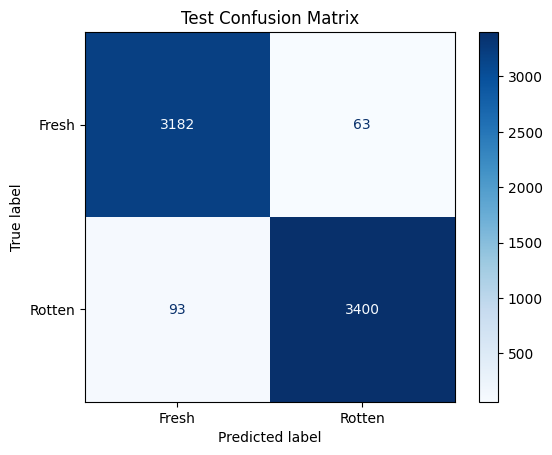

In [21]:
y_test_pred = np.argmax(model.predict(X_test), axis=1)

print("\n--- Test Classification Report ---")
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fresh', 'Rotten'])
disp.plot(cmap='Blues')
plt.title('Test Confusion Matrix')
plt.show()